In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [4]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


<Axes: xlabel='price', ylabel='Count'>

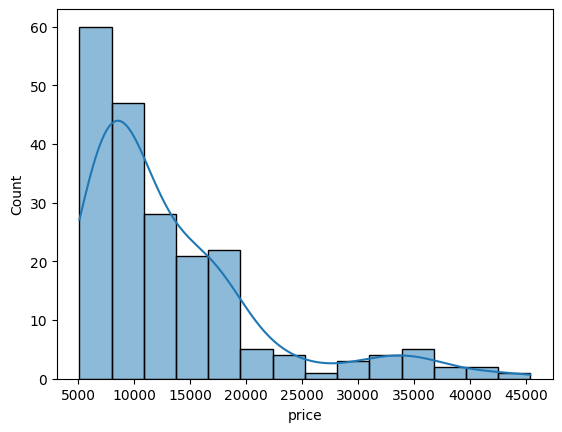

In [5]:
sns.histplot(x=df.price, kde=True)

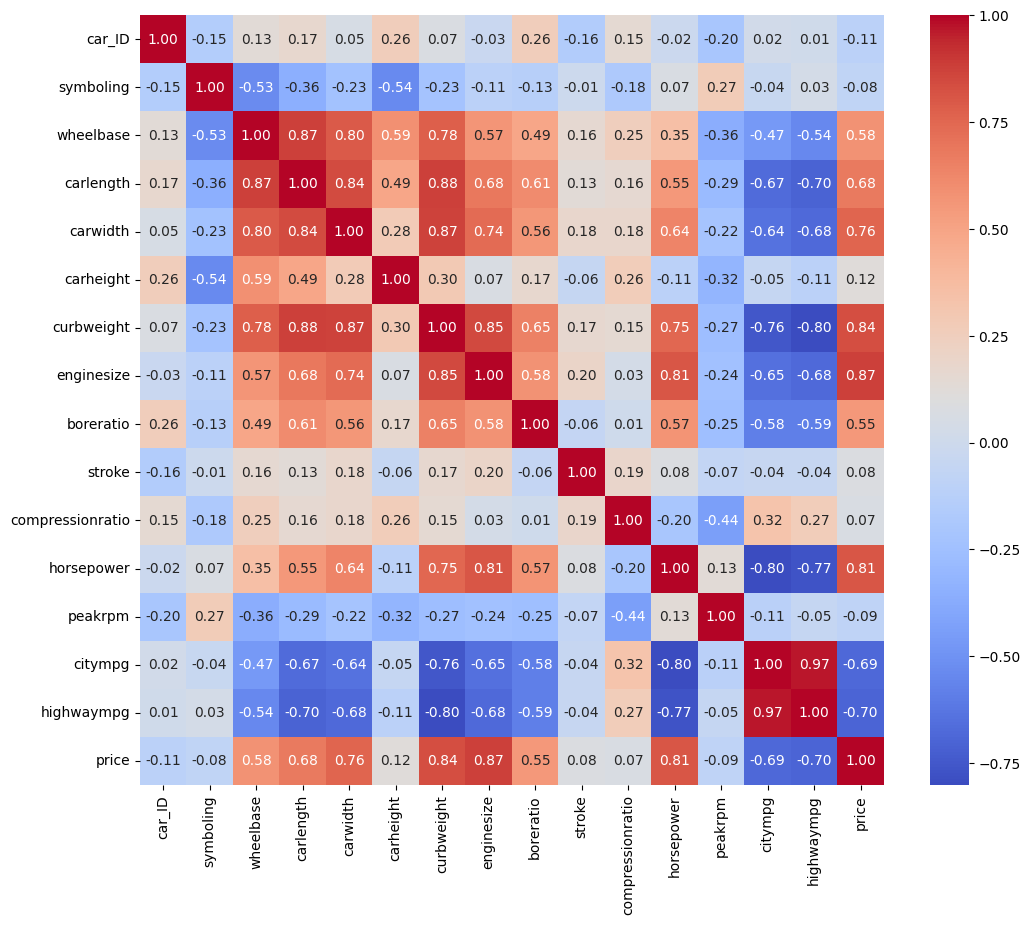

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

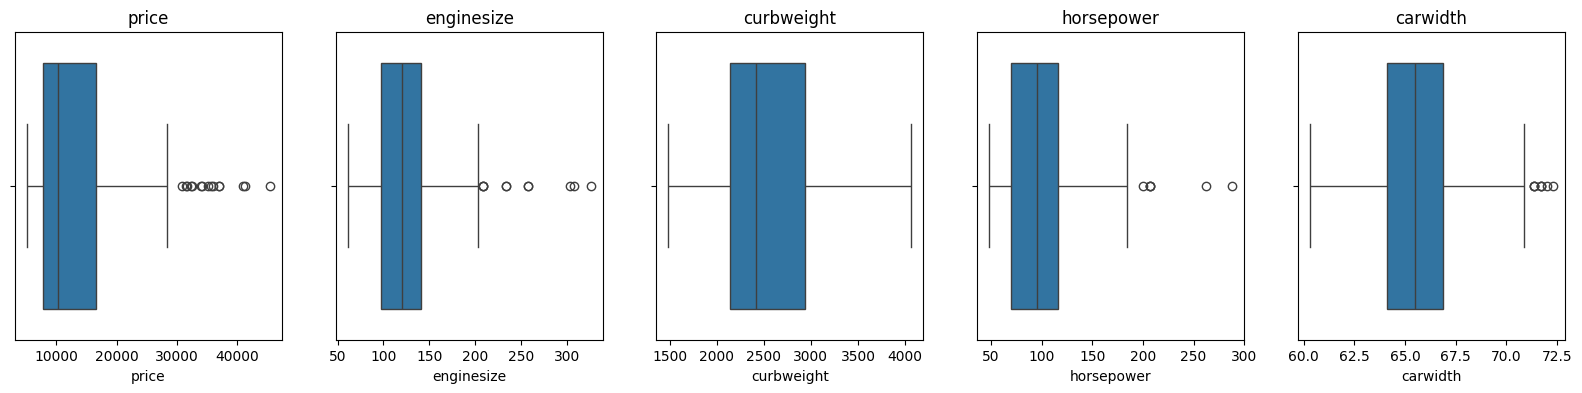

In [7]:
plt.figure(figsize=(20,4))

plt.subplot(1,5,1)
sns.boxplot(x=df['price'])
plt.title('price')

plt.subplot(1,5,2)
sns.boxplot(x=df['enginesize'])
plt.title('enginesize')

plt.subplot(1,5,3)
sns.boxplot(x=df['curbweight'])
plt.title('curbweight')

plt.subplot(1,5,4)
sns.boxplot(x=df['horsepower'])
plt.title('horsepower')

plt.subplot(1,5,5)
sns.boxplot(x=df['carwidth'])
plt.title('carwidth')

plt.show()

Checked outliers on price, enginesize, horsepower and carwidth using boxplots. These aren't random data errors, they're just expensive, high performance cars (bigger engines, more horsepower, wider bodies all pushing price up together). Since price is what we're trying to predict, replacing these with the median would basically erase the exact pattern the model needs to learn. Decided to leave them as is.

In [8]:
df['CarName'].nunique()

147

In [9]:
df = df.drop('CarName', axis=1)

In [10]:
df.select_dtypes(include='object').columns

Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem'],
      dtype='object')

In [11]:
df = pd.get_dummies(df, columns=['fueltype', 'aspiration', 'doornumber', 'carbody',
                                   'drivewheel', 'enginelocation', 'enginetype',
                                   'cylindernumber', 'fuelsystem'], drop_first=True)
df.head()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


In [12]:
df.shape

(205, 45)

In [13]:
df = df.drop('car_ID', axis=1)
df.shape

(205, 44)

In [14]:
X = df.drop('price', axis=1)
y = df['price']

In [15]:
X.shape
y.shape

(205,)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train.shape
X_test.shape

(41, 43)

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [19]:
y_pred_lr[:5]
y_test[:5]

,price
15,30760.000
9,17859.167
100,9549.000
132,11850.000
68,28248.000


In [20]:
print(y_pred_lr[:5])
print(y_test[:5])

[28611.52279852 19979.31003049 10737.02029364 12610.95309308
 27503.95566353]
15     30760.000
9      17859.167
100     9549.000
132    11850.000
68     28248.000
Name: price, dtype: float64


In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [22]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [23]:
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})
coef_comparison

,Feature,Linear,Ridge,Lasso
0,symboling,9.728010e+01,218.747331,92.889620
1,wheelbase,1.081695e+02,89.021707,107.902217
2,carlength,-8.217071e+01,-100.968296,-84.625598
3,carwidth,5.715243e+02,671.786549,572.172604
4,carheight,1.112606e+02,251.136708,120.331778
5,curbweight,3.773380e+00,3.571763,3.730477
6,enginesize,1.238998e+02,127.408875,126.643385
7,boreratio,-2.107428e+03,-1647.426231,-2102.738430
8,stroke,-3.874928e+03,-3302.501453,-3867.336291
9,compressionratio,-2.735093e+02,-39.836094,-164.443557


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

lr_scores = evaluate(y_test, y_pred_lr)
ridge_scores = evaluate(y_test, y_pred_ridge)
lasso_scores = evaluate(y_test, y_pred_lasso)

In [25]:
comparison_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'MAE': [lr_scores[0], ridge_scores[0], lasso_scores[0]],
    'MSE': [lr_scores[1], ridge_scores[1], lasso_scores[1]],
    'RMSE': [lr_scores[2], ridge_scores[2], lasso_scores[2]],
    'R2': [lr_scores[3], ridge_scores[3], lasso_scores[3]]
})
comparison_table

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2089.382729,8.482008e+06,2912.388793,0.892557
1,Ridge,2068.126110,9.863953e+06,3140.693136,0.875051
2,Lasso,2096.392815,8.664091e+06,2943.482807,0.890250


Key Insights



1.   Linear Regression came out on top, R² around 0.89, RMSE around 2912
2.   Lasso was pretty close behind it, not far off at all


1.   Ridge lagged a little compared to the other two
2.   Regularization didn't do much here since Linear Regression wasn't really overfitting in the first place





